# Wind Turbine Experimental Data Visualization Tool

This notebook is designed to easily visualize various experimental data (resistance, power, voltage, current, etc.).

## How to Use
0. The Dataset should be uploaded here:
https://drive.google.com/drive/folders/115T7YsGx1EHJLYIa-piAbEpjV60-vW_y
1. Run the **[Setup & Load Data]** cell first. (Wait for a new google login window to pop up. If it doesn't, stop the code and restart it)
2. Go to the **[2D Graph]** or **[3D Graph]** cells, change the variable names, and run them.
    * **2D Graph:** `graph_2d("filename.csv", "Variable 1", "Variable 2", ...)`
   * **3D Graph:** `graph_3d("filename.csv", "X-axis Variable", "Y-axis Variable", "Z-axis Variable")`
    * If your file is inside certain folder, for example **"test4.csv"** file in folder named **"testing_2-15-2026"** which should be under ".../WEC_Electronics/Data" then file name should be **"testing_2-15-2026/test4.csv"**.

## Available Variables (Column Names)
Copy and paste the names exactly as written below:
* `Time`
* `Set Resistance`
* `Set Voltage`
* `Set Current`
* `Set Power`
* `Load Resistance`
* `Load Voltage`
* `Load Current`
* `Load Power`
* `DAC Output`
* `Servo Position`
* `Wind Speed`

###1. Set up & Load Data
⬇️Click here


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
def load_data(f):
    return pd.read_csv("/content/drive/MyDrive/WEC_Electronics/Data/"+f)

def graph_2d(filename, *vars):
    df = load_data(filename)
    plt.figure(figsize=(12, 6))
    for col in vars:
        plt.plot(df["Time"], df[col], label=col, linewidth=1.5)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f"Time vs {', '.join(vars)}", fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def graph_3d(filename, x_col, y_col, z_col):
    df = load_data(filename)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3D Scatter plot (Color mapped to the Z-axis variable)
    sc = ax.scatter(df[x_col], df[y_col], df[z_col],
                    c=df[z_col], cmap='viridis', s=20, alpha=0.6)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    plt.title(f'3D Analysis: {x_col} vs {y_col} vs {z_col}', fontweight='bold')

    # Add a color bar
    plt.colorbar(sc, label=z_col)
    plt.show()

###2. 2D Graph

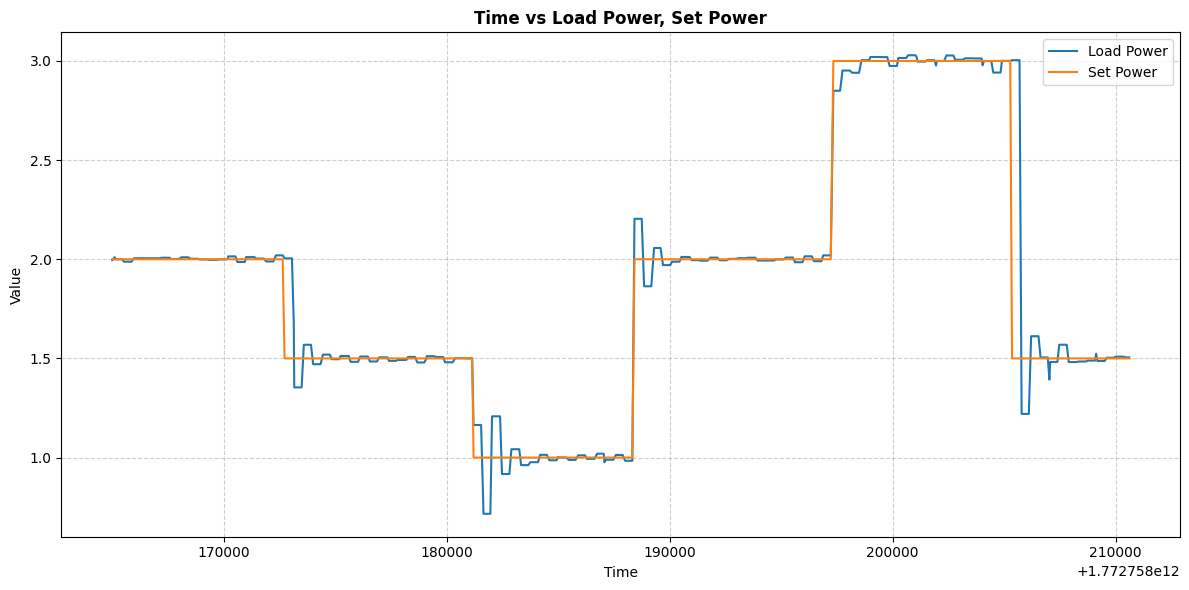

In [4]:
#graph_2d("filename.csv")
graph_2d("data030526.csv", "Load Power", "Set Power")

#graph_2d("pid_data3.csv", "Load Resistance", "Set Resistance")

###3. 3D Graph

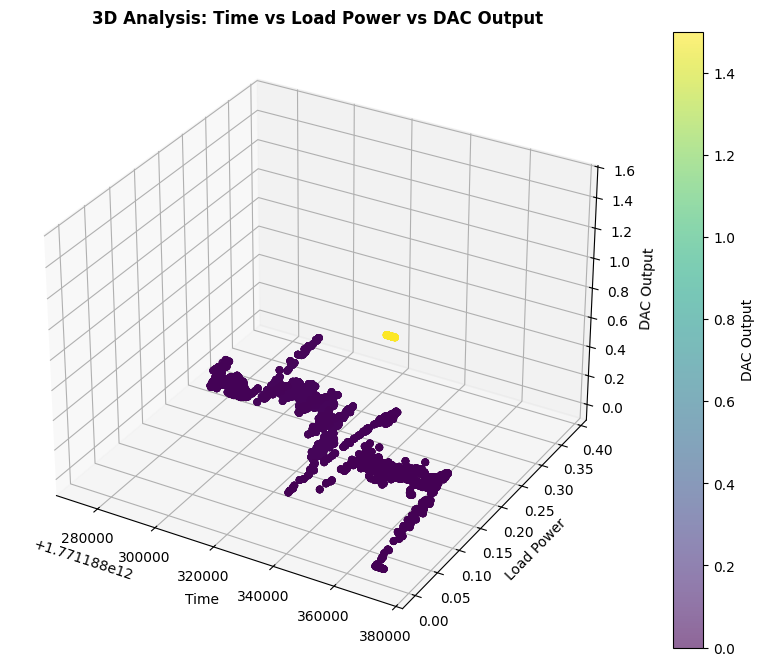

In [6]:
graph_3d("testing_2-15-2026/test4.csv", "Time", "Load Power", "DAC Output")